In [2]:
# Get the extent (bounding polygon) from a raster file, in WGS84 (required by osmnx)
from pathlib import Path

import geopandas as gpd
from rasterio import open as rio_open
from shapely.geometry import box

import osmnx
import pandas as pd

In [3]:
healthcare_tags = {
    "amenity": [
        "hospital",
        "doctors",
        "clinic"
    ]
}

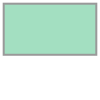

In [7]:
repo_path = Path(r"C:\repos\powerpath\powerpath")
raster_path = repo_path / "raw_data" / "hazard_maps_timesteps_tif" / "timestep_1.tif"

with rio_open(raster_path) as src:
    raster_bounds = box(*src.bounds)
    raster_crs = src.crs

extent_gdf = gpd.GeoDataFrame(geometry=[raster_bounds], crs=raster_crs).to_crs(epsg=4326)
extent_polygon = extent_gdf.geometry.iloc[0]
extent_polygon

In [8]:
# Extract amenities (both point and polygon features) within the extent
amenities = osmnx.features_from_polygon(extent_polygon, tags=healthcare_tags)
amenities = amenities.reset_index()
amenities.geom_type.value_counts()

Point      309
Polygon     39
Name: count, dtype: int64

In [20]:
# Split into point and polygon geometries
point_amenities = amenities[amenities.geom_type == "Point"].copy()
polygon_amenities = amenities[amenities.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# Use the polygon's centroid to represent it for the point-in-polygon comparison
# polygon_amenities["centroid"] = polygon_amenities.geometry.centroid

print(f"Points: {len(point_amenities)}, Polygons: {len(polygon_amenities)}")

Points: 309, Polygons: 39


In [23]:
# Find points that fall within a polygon (same real-world amenity mapped twice) and drop them, keeping the polygon
overlap = gpd.sjoin(
    point_amenities,
    polygon_amenities[["geometry"]],
    how="left",
    predicate="within",
)

duplicate_point_idx = overlap.loc[overlap["index_right"].notna()].index
point_amenities_deduped = point_amenities.drop(index=duplicate_point_idx)



print(f"Points removed as duplicates of a polygon: {len(duplicate_point_idx)}")
print(f"Remaining points: {len(point_amenities_deduped)}, Polygons: {len(polygon_amenities)}")

Points removed as duplicates of a polygon: 6
Remaining points: 303, Polygons: 39


In [ ]:
import pandas as pd
import numpy as np
import re

# -----------------------------------------------------------------------------
# 1. Identify healthcare facilities
# -----------------------------------------------------------------------------

KEEP_PATTERNS = [
    r"huisartsenpraktijk",
    r"huisartsenpost",
    r"huisartsen",
    r"\bhuisarts\b",
    r"gezondheidscentrum",
    r"medisch centrum",
    r"doktershuis",
    r"therapeuticum",
    r"erasmus",
    r"hmc",
    r"haga",
    r"franciscus",
    r"reinier",
    r"oogziekenhuis",
    r"spoedeisende hulp",
    r"basalt",
    r"rijndam",
    r"ggz",
    r"parnassia",
    r"psyq",
    r"fivoor",
    r"bergman",
    r"dc klinieken",
    r"annatommie",
    r"eyescan",
    r"holland ptc",
    r"andros",
    r"gynos",
    r"international health centre",
    r"archimedes medisch centrum",
    r"artsenzorg",
    r"arts en zorg",
    r"de doc huisartsen",
    r"zorgcentrum",
    r"jgz",
    r"jeugd gezondheidszorg",
]

EXCLUDE_PATTERNS = [
    r"fysio",
    r"fysiotherapie",
    r"chiropr",
    r"homeopath",
    r"acupunct",
    r"tandarts",
    r"mondhy",
    r"pedicure",
    r"podotherapie",
    r"logoped",
    r"laser",
    r"injectable",
    r"cosmetic",
    r"travel clinic",
    r"eyebank",
    r"voet",
    r"borstvoeding",
    r"vroedvrouw",
    r"verloskundige",
    r"osteo",
]

def keep_healthcare_facility(name):

    if pd.isna(name):
        return False

    name = str(name).lower().strip()

    if any(re.search(p, name) for p in EXCLUDE_PATTERNS):
        return False

    if any(re.search(p, name) for p in KEEP_PATTERNS):
        return True

    return False

# -----------------------------------------------------------------------------
# 2. Keep only relevant healthcare facilities
# -----------------------------------------------------------------------------

point_healthcare = (
    point_amenities_deduped[
        point_amenities_deduped["name"].apply(keep_healthcare_facility)
    ]
    .copy()
)

polygon_healthcare = (
    polygon_amenities[
        polygon_amenities["name"].apply(keep_healthcare_facility)
    ]
    .copy()
)

# -----------------------------------------------------------------------------
# 3. Assign PowerPath asset type using existing taxonomy
# -----------------------------------------------------------------------------

TYPE_MAPPING = {
    "hospital": "health",
    "clinic": "health",
    "doctors": "health",
    "apotheek": "health",
}

def assign_type(row):

    amenity = str(row.get("amenity", "")).lower()
    healthcare = str(row.get("healthcare", "")).lower()

    if amenity in TYPE_MAPPING:
        return TYPE_MAPPING[amenity]

    if healthcare in TYPE_MAPPING:
        return TYPE_MAPPING[healthcare]

    return np.nan

point_healthcare["type"] = point_healthcare.apply(assign_type, axis=1)
polygon_healthcare["type"] = polygon_healthcare.apply(assign_type, axis=1)

# -----------------------------------------------------------------------------
# 4. Show anything that survived healthcare filtering but cannot be mapped
#    to an existing PowerPath type
# -----------------------------------------------------------------------------

unclassified_points = point_healthcare[point_healthcare["type"].isna()]
unclassified_polygons = polygon_healthcare[polygon_healthcare["type"].isna()]

print("\nUNCLASSIFIED HEALTHCARE POINTS")

if len(unclassified_points):
    cols = [c for c in ["name", "amenity", "healthcare"] if c in unclassified_points.columns]
    print(
        unclassified_points[cols]
        .drop_duplicates()
        .sort_values("name")
        .to_string(index=False)
    )
else:
    print("None")

print("\nUNCLASSIFIED HEALTHCARE POLYGONS")
if len(unclassified_polygons):
    cols = [c for c in ["name", "amenity", "healthcare"] if c in unclassified_polygons.columns]
    print(
        unclassified_polygons[cols]
        .drop_duplicates()
        .sort_values("name")
        .to_string(index=False)
    )
else:
    print("None")

# -----------------------------------------------------------------------------
# 5. Keep only facilities that are both relevant and mapped
# -----------------------------------------------------------------------------

point_healthcare = point_healthcare[
    point_healthcare["type"].notna()
].copy()

polygon_healthcare = polygon_healthcare[
    polygon_healthcare["type"].notna()
].copy()

# -----------------------------------------------------------------------------
# 6. Merge and review final inventory
# -----------------------------------------------------------------------------

healthcare = pd.concat(
    [point_healthcare, polygon_healthcare],
    ignore_index=True
)

healthcare = (
    healthcare
    .drop_duplicates(subset=["name"])
    .sort_values("name")
)

print(f"\nSelected {len(healthcare)} healthcare facilities")

for name in healthcare["name"].dropna():
    print(name)


UNCLASSIFIED HEALTHCARE POINTS
None

UNCLASSIFIED HEALTHCARE POLYGONS
None

Selected 199 healthcare facilities
A.P.M.T. Bruijs huisarts
Akelei huisartsenzorg
Andros Mannenkliniek
Annatommie
Archimedes Medisch Centrum & Apotheek
Arts en Zorg
ArtsEnZorg
Artsenzorg
Baggerman & Harderwijk Huisartsen
Basalt Revalidatie
Basalt revalidatie Den Haag
Bergman Clinics
Bergman clinics
Cool Huisartsencentrum
DC Klinieken
De Doc Huisartsen
De Haagsche Huisarts
De Hand Paramedisch Centrum
Doktershuis Oude Noorden
Erasmus Medisch Centrum
Erasmus Medisch Centrum Derma- en Kinderhaven
Eyescan
Fivoor
Forum Huisartsen
Franciscus Berkel
Franciscus Gasthuis
Franciscus Maassluis
Franciscus Vlietland
GGZ Delfland
Gezondheidscentrum
Gezondheidscentrum Afrikaanderwijk
Gezondheidscentrum Badhuisweg
Gezondheidscentrum Berkel en Rodenrijs
Gezondheidscentrum Buytenwegh
Gezondheidscentrum Calandria
Gezondheidscentrum CareXL
Gezondheidscentrum De Beek
Gezondheidscentrum De Koning
Gezondheidscentrum De Leyens
Gezondh

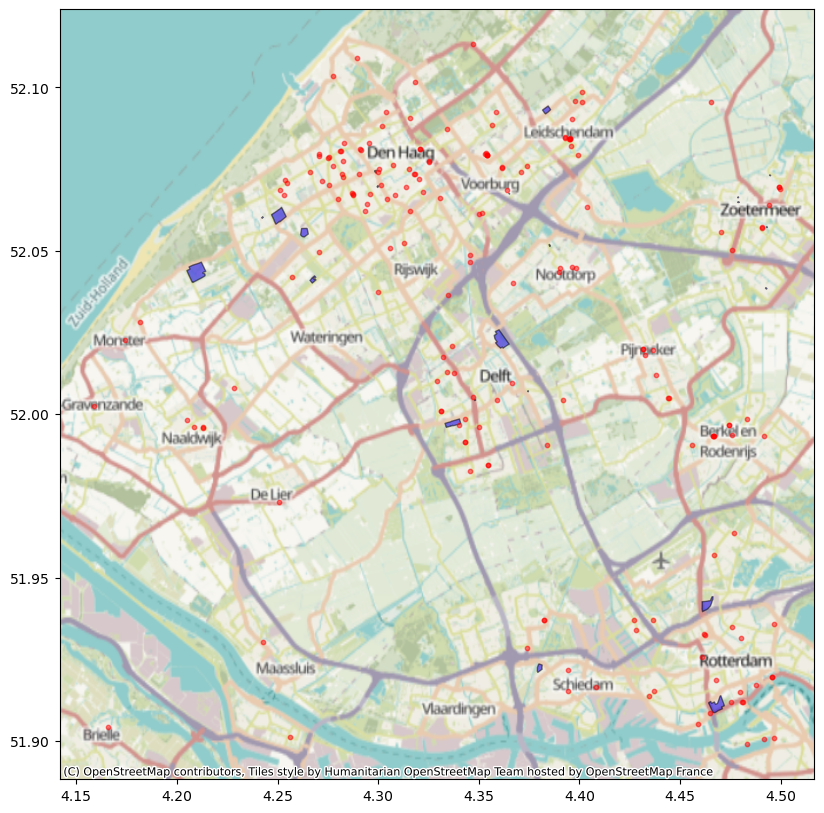

In [41]:
# Interactive plot of all mapped amenities with base map, with callouts for hospitals
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))
polygon_healthcare.plot(ax=ax, color="blue", alpha=0.5, edgecolor="k")
point_healthcare.plot(ax=ax, color="red", alpha=0.5, markersize=10)

ctx.add_basemap(ax, crs=polygon_healthcare.crs.to_string())
plt.show()

In [43]:
output_path = repo_path / "data" / "static" / "healthcare_amenities.gpkg"
output_path.parent.mkdir(parents=True, exist_ok=True)
healthcare.to_file(output_path, driver="GPKG")

healthcare[['name','type']]

,name,type
109,A.P.M.T. Bruijs huisarts,health
110,Akelei huisartsenzorg,health
100,Andros Mannenkliniek,health
53,Annatommie,health
102,Archimedes Medisch Centrum & Apotheek,health
...,...,...
194,Therapeuticum Aurum,health
147,Von Asmuth Huisartsen,health
62,Zorgcentrum Akram,health
67,Zuiderpark Huisartsen,health
